# Predicción de Abandono Temprano en Spotify — TP Minería de Datos (UTDT)
## Historial fino por (usuario, canción) y (usuario, artista)

Competencia Kaggle: predecir si una reproducción es "abandono temprano" (`ms_played < 30000`). Métrica: ROC-AUC.

**Primer notebook post-clases** (las 5 clases del curso ya están vistas y aplicadas): ejecuta el siguiente paso del plan de mejora del score acordado al cierre de las Clases 4–5. Parte de la **base mínima heredada de las Clases 1–5** (carga, target, feature set con las columnas de la API, receta de Optuna, CV temporal, ventana de 24 meses — todo cerrado; la justificación vive en los notebooks anteriores) y el cuerpo son las features de **historial fino**: qué hizo *este usuario* con *esta canción / este artista* en el pasado. Dos familias con estatus metodológico distinto, tratadas distinto a propósito:

- **Historial de metadata** (conteos y recencia por usuario×entidad): calculable fila a fila con `ts`/`user_id`/URI, que el test estático de Kaggle trae completos — misma legitimidad batch que `gap_min`/`bucket_count_30min`. En la CV expande libre, estrictamente hacia el pasado.
- **Historial de target** (skip-rate por usuario×entidad): es el *bin counting/target encoding* de la Clase 3 en versión temporal — usa el target de filas **pasadas**. En el escenario real no hay labels dentro del período de test, así que acá la disciplina es más dura: para las filas de validación de cada fold, las tasas se **congelan en el borde del fold** (solo lo etiquetado hasta ahí); para las filas de entrenamiento, expanding estrictamente pasado. Se incluye además un **experimento de control con la versión CON fuga** (expandir a través del borde) para cuantificar cuánto inflaría la CV — el espíritu del experimento de ruido de la Clase 3.

Cierre de siempre: re-tuneo corto con Optuna (el feature set cambia bastante), re-test de ventana, **una única mirada** a `test_interno`, submission con el 100% de train. Decisiones **solo** contra la CV temporal, nunca contra el leaderboard.

Progreso en vivo en **`progreso_historial.log`** (corrida completa: ~25 min; el re-tuneo es el bloque más largo).

## Base heredada de las Clases 1–5 (mínima)

Carga, target y derivadas de la Clase 1; validación de la Clase 2 (`test_interno` 15% + CV de ventana expansiva, 4 folds; ventana de train 24 meses, re-validada cuatro veces); numéricas de comportamiento de las Clases 3–4; columnas de la API de Spotify de la Clase 5 (las 8 adoptadas); XGBoost sobre matrices ralas con la **receta de Optuna de la Clase 5** (`depth=7, eta≈0.030, mcw=2, sub≈0.80, col≈0.79, gamma≈0.84`). El cluster de canciones quedó rechazado en la Clase 5 y no se hereda.

Números fijos a superar (Clase 5): **AUC CV 0.8420** (se reproduce abajo como sanidad), **`test_interno` 0.8377**, Kaggle público 0.84993.

In [1]:
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse as sp
import xgboost as xgb
import optuna

from sklearn.metrics import roc_auc_score

RANDOM_STATE = 42
DATA_DIR = "../competition_data"
LOG_HIST = "../logs/progreso_historial.log"

# Estilo unico (misma paleta validada de las Clases 4-5).
C_AZUL, C_AQUA, C_AMARILLO = "#2a78d6", "#1baf7a", "#eda100"
C_TEXTO, C_MUTED, C_GRILLA, C_EJES = "#0b0b0b", "#898781", "#e1e0d9", "#c3c2b7"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": C_GRILLA, "grid.linewidth": 0.8,
    "axes.edgecolor": C_EJES, "axes.labelcolor": C_TEXTO,
    "xtick.color": C_MUTED, "ytick.color": C_MUTED,
})

open(LOG_HIST, "w", encoding="utf-8").close()


def log_progreso(msg):
    """Mismo sistema de las Clases 4-5: timestamp, print y linea appendeada al log."""
    linea = f"[{time.strftime('%H:%M:%S')}] {msg}"
    print(linea, flush=True)
    with open(LOG_HIST, "a", encoding="utf-8") as flog:
        flog.write(linea + "\n")


optuna.logging.set_verbosity(optuna.logging.WARNING)
log_progreso(f"Historial fino -- xgboost {xgb.__version__} | optuna {optuna.__version__}")

[22:36:34] Historial fino -- xgboost 3.2.0 | optuna 4.9.0


In [2]:
USECOLS = [
    "obs_id", "ms_played", "ts", "platform_family", "conn_country",
    "master_metadata_album_artist_name",
    "spotify_track_uri", "spotify_episode_uri", "audiobook_uri",
    "shuffle", "offline", "incognito_mode", "user_id",
]
DTYPES = {
    "spotify_track_uri": "string", "spotify_episode_uri": "string", "audiobook_uri": "string",
}

train_raw = pd.read_csv(f"{DATA_DIR}/train_data.txt", sep="\t", usecols=USECOLS, dtype=DTYPES, low_memory=False)
train_raw["target"] = (train_raw["ms_played"] < 30000).astype(int)

train_raw["content_type"] = np.select(
    [train_raw["spotify_track_uri"].notna(),
     train_raw["spotify_episode_uri"].notna(),
     train_raw["audiobook_uri"].notna()],
    ["track", "episode", "audiobook"],
    default="desconocido",
)
ts_dt = pd.to_datetime(train_raw["ts"], utc=True, format="ISO8601")
train_raw["ts_dt"] = ts_dt
train_raw["hora"] = ts_dt.dt.hour
DIAS = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
train_raw["dia_semana"] = ts_dt.dt.dayofweek.map(dict(enumerate(DIAS)))

col_artista = "master_metadata_album_artist_name"
TOP_ARTISTAS = train_raw[col_artista].value_counts().head(50).index
train_raw["artista_top"] = train_raw[col_artista].where(train_raw[col_artista].isin(TOP_ARTISTAS), "otros")

train_raw = train_raw.sort_values(["ts_dt", "obs_id"]).reset_index(drop=True)
log_progreso(f"train cargado: {len(train_raw):,} filas | tasa de abandono {train_raw['target'].mean():.4f}")

[22:36:38] train cargado: 911,344 filas | tasa de abandono 0.2780


In [3]:
n = len(train_raw)
n_train = int(n * 0.85)
df_train = train_raw.iloc[:n_train].copy()
df_test_interno = train_raw.iloc[n_train:].copy()

for nombre, df in [("train", df_train), ("test interno", df_test_interno)]:
    print(f"{nombre:<13} {len(df):>7,} filas | {df['ts_dt'].min().date()} -> {df['ts_dt'].max().date()} "
          f"| tasa abandono {df['target'].mean():.4f}")

train         774,642 filas | 2013-10-29 -> 2023-05-26 | tasa abandono 0.2865
test interno  136,702 filas | 2023-05-26 -> 2024-08-31 | tasa abandono 0.2298


In [4]:
# Numericas heredadas (Clases 3-4), sobre train+test_interno concatenados (misma logica de siempre).
full = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"])

gap = full.groupby("user_id")["ts_dt"].diff().dt.total_seconds() / 60.0
full["gap_min"] = gap.fillna(-1)
full["bucket_count_30min"] = full.groupby(["user_id", "ts"])["obs_id"].transform("size")
full["pos_en_bucket"] = full.groupby(["user_id", "ts"]).cumcount()
fecha = full["ts_dt"].dt.floor("D")
full["bucket_count_dia"] = full.groupby(["user_id", fecha])["obs_id"].transform("size")
gap_sig = (full.groupby("user_id")["ts_dt"].shift(-1) - full["ts_dt"]).dt.total_seconds() / 60.0
full["gap_siguiente"] = gap_sig.fillna(-1)

df_train = full.loc[df_train.index]
df_test_interno = full.loc[df_test_interno.index]
log_progreso("numericas heredadas listas (Clases 3-4)")

[22:36:40] numericas heredadas listas (Clases 3-4)


In [5]:
# Columnas de la API de Spotify (Clase 5, las 8 adoptadas). Mismo helper de la Clase 5.
api = pd.read_pickle(f"{DATA_DIR}/api_features.pkl")
api_idx = api.set_index("uri")


def agregar_columnas_api(df):
    """Mapea la metadata de la API por URI y construye las derivadas adoptadas en la Clase 5.
    Requiere ts_dt y bucket_count_30min ya calculados."""
    df["uri"] = df["spotify_track_uri"].fillna(df["spotify_episode_uri"])
    df["duracion_ms"] = df["uri"].map(api_idx["duration_ms"])
    df["popularity"] = df["uri"].map(api_idx["popularity"])
    df["explicit_num"] = df["uri"].map(api_idx["explicit"].astype(float))
    df["track_number"] = df["uri"].map(api_idx["track_number"])
    df["album_total_tracks"] = df["uri"].map(api_idx["album_total_tracks"])

    rel = df["uri"].map(api_idx["release_date"]).astype("string")
    rel = rel.where(rel.str.len() != 4, rel + "-01-01")
    rel = rel.where(rel.str.len() != 7, rel + "-01")
    release_dt = pd.to_datetime(rel, errors="coerce", utc=True)
    df["antiguedad_dias"] = (df["ts_dt"] - release_dt).dt.days.astype(float)

    dur = df["duracion_ms"]
    df["dur_menor_30s"] = np.where(dur.isna(), np.nan, (dur < 30000).astype(float))
    df["carga_bucket"] = df["bucket_count_30min"] * dur / (30 * 60 * 1000)
    return df


full = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"])
full = agregar_columnas_api(full)
df_train = full.loc[df_train.index]
df_test_interno = full.loc[df_test_interno.index]
log_progreso(f"columnas de la API listas | cobertura {full['duracion_ms'].notna().mean():.1%}")

[22:36:43] columnas de la API listas | cobertura 99.9%


In [6]:
TODAS_LAS_FEATURES = ["platform_family", "conn_country", "shuffle", "offline", "incognito_mode",
                      "hora", "dia_semana", "content_type", "artista_top"]
CAT_FINAL = [f for f in TODAS_LAS_FEATURES if f != "hora"] + ["user_id"]
NUM_FINAL = ["gap_min", "bucket_count_30min", "pos_en_bucket", "bucket_count_dia", "gap_siguiente", "hora",
             "duracion_ms", "dur_menor_30s", "carga_bucket", "popularity", "antiguedad_dias",
             "explicit_num", "track_number", "album_total_tracks"]

# Receta ganadora de Optuna en la Clase 5 (trial 26), con los floats exactos.
RECETA_5 = dict(max_depth=7, eta=0.030223664895420776, min_child_weight=2,
                subsample=0.7963585977878456, colsample_bytree=0.79208902443077,
                gamma=0.8414960952850874)
BASE_PARAMS_XGB = dict(objective="binary:logistic", eval_metric="auc", seed=RANDOM_STATE)
NUM_BOOST_MAX, EARLY_STOP, N_FOLDS = 600, 25, 4
VENTANA_HEREDADA = 24

AUC_CLASE5_CV, AUC_CLASE5_TEST, SCORE_CLASE5_KAGGLE = 0.8420, 0.8377, 0.84993


def filtrar_reciente(df, meses):
    if meses is None:
        return df
    corte = df["ts_dt"].max() - pd.DateOffset(months=int(meses))
    return df[df["ts_dt"] >= corte]


def make_expanding_folds(df, n_folds=4):
    n = len(df)
    bordes = np.linspace(0, n, n_folds + 2, dtype=int)
    folds = []
    for i in range(1, n_folds + 1):
        idx_train = np.arange(0, bordes[i])
        idx_val = np.arange(bordes[i], bordes[i + 1])
        if len(idx_val) > 0 and len(idx_train) > 0:
            folds.append((idx_train, idx_val))
    return folds


def limpiar_nombres_columnas(cols):
    limpios = [re.sub(r"[\[\]<]", "_", str(c)) for c in cols]
    vistos, out = {}, []
    for c in limpios:
        if c in vistos:
            vistos[c] += 1
            out.append(f"{c}__dup{vistos[c]}")
        else:
            vistos[c] = 0
            out.append(c)
    return out


def build_sparse_matrix(df, cat_features, num_features):
    cat_features = list(cat_features)
    cat_dummies = pd.get_dummies(df[cat_features], columns=cat_features, dummy_na=True, sparse=True)
    X_cat = sp.csr_matrix(cat_dummies.sparse.to_coo())
    X_num = sp.csr_matrix(df[list(num_features)].astype(float).values)
    X = sp.hstack([X_cat, X_num], format="csr")
    feature_names = limpiar_nombres_columnas(list(cat_dummies.columns.astype(str)) + list(num_features))
    y = df["target"].to_numpy()
    return X, y, feature_names


def entrenar_fold(dtr, dva, params):
    bst = xgb.train({**BASE_PARAMS_XGB, **params}, dtr, num_boost_round=NUM_BOOST_MAX,
                    evals=[(dva, "val")], early_stopping_rounds=EARLY_STOP, verbose_eval=False)
    return float(bst.best_score), bst.best_iteration + 1


def evaluar_cv(cat_feats, num_feats, params, ventana=VENTANA_HEREDADA, etiqueta="", df=None):
    """CV temporal estandar para features 'estaticas' (columnas ya presentes en df, sin
    dependencia del fold). df=None se resuelve adentro (gotcha de las Clases 4-5)."""
    if df is None:
        df = df_train
    t0 = time.time()
    X, y, nombres = build_sparse_matrix(df, cat_feats, num_feats)
    aucs, rondas = [], []
    for idx_tr, idx_val in make_expanding_folds(df, n_folds=N_FOLDS):
        if ventana is not None:
            corte = df["ts_dt"].iloc[idx_tr].max() - pd.DateOffset(months=int(ventana))
            idx_tr = idx_tr[(df["ts_dt"].iloc[idx_tr] >= corte).to_numpy()]
        dtr = xgb.DMatrix(X[idx_tr], label=y[idx_tr], feature_names=nombres)
        dva = xgb.DMatrix(X[idx_val], label=y[idx_val], feature_names=nombres)
        auc_f, r_f = entrenar_fold(dtr, dva, params)
        aucs.append(auc_f)
        rondas.append(r_f)
    auc = float(np.mean(aucs))
    if etiqueta:
        detalle = " ".join(f"{a:.4f}" for a in aucs)
        aviso = " | OJO: cerca del tope de rondas" if np.mean(rondas) >= 580 else ""
        log_progreso(f"{etiqueta:<52s} -> AUC CV {auc:.4f} | folds [{detalle}] | rondas prom {np.mean(rondas):3.0f} | {time.time() - t0:4.0f}s{aviso}")
    return auc, aucs, float(np.mean(rondas)), X.shape[1]


print(f"CAT_FINAL ({len(CAT_FINAL)}) | NUM_FINAL ({len(NUM_FINAL)})")
print(f"Receta heredada (Optuna Clase 5): {RECETA_5}")
print(f"A superar -- AUC CV: {AUC_CLASE5_CV:.4f} | test_interno: {AUC_CLASE5_TEST:.4f} | Kaggle: {SCORE_CLASE5_KAGGLE}")

CAT_FINAL (9) | NUM_FINAL (14)
Receta heredada (Optuna Clase 5): {'max_depth': 7, 'eta': 0.030223664895420776, 'min_child_weight': 2, 'subsample': 0.7963585977878456, 'colsample_bytree': 0.79208902443077, 'gamma': 0.8414960952850874}
A superar -- AUC CV: 0.8420 | test_interno: 0.8377 | Kaggle: 0.84993


### Sanidad: reproducir la referencia de la Clase 5 antes de tocar nada

Misma regla de siempre: si esta corrida no reproduce el **0.8420** del cierre de la Clase 5 (mismo feature set, misma receta, misma semilla), ninguna comparación posterior vale.

In [7]:
log_progreso("=== Sanidad: reproducir la referencia de la Clase 5 ===")
AUC_REF, _, RONDAS_REF, COLS_REF = evaluar_cv(CAT_FINAL, NUM_FINAL, RECETA_5,
                                              etiqueta="referencia heredada (esperado 0.8420)")
if abs(AUC_REF - AUC_CLASE5_CV) > 0.0005:
    log_progreso(f"ATENCION: la referencia ({AUC_REF:.4f}) no reproduce el {AUC_CLASE5_CV:.4f} esperado")
else:
    log_progreso(f"sanidad OK: referencia {AUC_REF:.4f} ({COLS_REF} columnas)")

[22:36:43] === Sanidad: reproducir la referencia de la Clase 5 ===
[22:37:35] referencia heredada (esperado 0.8420)                -> AUC CV 0.8420 | folds [0.7872 0.8428 0.8915 0.8465] | rondas prom 330 |   52s
[22:37:35] sanidad OK: referencia 0.8420 (149 columnas)


## Cuerpo: historial fino por (usuario, entidad)

La intuición: el modelo hoy sabe *cuánta actividad* tiene el usuario (conteos, gaps) y *qué* está sonando (API, artista top), pero no sabe **qué relación tiene este usuario con esta canción concreta** — ¿la escucha por primera vez o por centésima? ¿la escuchó hace 10 minutos o hace un año? ¿la corta siempre o nunca? Con 10 usuarios y ~1.5 años de test real por delante, esta memoria es la señal de comportamiento más específica que nos queda sin explotar.

Cinco grupos, evaluados con el protocolo acumulativo de siempre (cada uno sobre lo ya adoptado; queda solo si el AUC CV sube estrictamente). Los dos primeros son **historial de metadata**; los tres últimos, **historial de target** con la disciplina del borde explicada arriba:

1. **H1 — (usuario, canción), metadata**: `u_track_veces` (cuántas veces la reprodujo antes — expanding estricto) y `u_track_recencia` (minutos desde la vez anterior; −1 = primera vez, mismo sentinela que `gap_min`).
2. **H2 — (usuario, artista), metadata**: `u_art_veces`, `u_art_recencia` — ídem sobre el nombre de artista completo (sin tope: acá el artista es *clave de agrupación*, no columna one-hot — la cardinalidad no expande la matriz).
3. **H3 — skip-rate (usuario, canción)**: `u_track_skip_rate` — de las veces anteriores *etiquetadas*, qué fracción cortó antes de 30 s. NaN si no hay historia etiquetada (XGBoost lo rutea).
4. **H4 — skip-rate (usuario, artista)**: `u_art_skip_rate`.
5. **H5 — skip-rates globales**: `user_skip_rate` (tasa histórica del usuario, toda su actividad — el "momentum" del diagnóstico) y `track_skip_rate` (tasa histórica de la canción entre todos los usuarios).

URIs/artistas faltantes (~0.1%) se rellenan con claves-sentinela (`sin_uri`/`sin_artista`) para que los groupby no tengan casos borde con NaN — quedan como una pseudo-entidad más.

In [8]:
# H1/H2: historial de metadata, expanding estricto sobre train+test_interno concatenados
# (misma legitimidad batch que gap_min: ts/user/uri estan completos en el test estatico).
full = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"])
full["uri_key"] = full["uri"].fillna("sin_uri")
full["artista_key"] = full[col_artista].fillna("sin_artista")

gt = full.groupby(["user_id", "uri_key"], sort=False)
full["u_track_veces"] = gt.cumcount()
full["u_track_recencia"] = (gt["ts_dt"].diff().dt.total_seconds() / 60.0).fillna(-1)

ga = full.groupby(["user_id", "artista_key"], sort=False)
full["u_art_veces"] = ga.cumcount()
full["u_art_recencia"] = (ga["ts_dt"].diff().dt.total_seconds() / 60.0).fillna(-1)

df_train = full.loc[df_train.index]
df_test_interno = full.loc[df_test_interno.index]

re_escucha = (df_train["u_track_veces"] > 0).mean()
re_artista = (df_train["u_art_veces"] > 0).mean()
log_progreso(f"historial de metadata listo | re-escuchas de cancion: {re_escucha:.1%} de las filas | "
             f"re-escuchas de artista: {re_artista:.1%}")
print(df_train[["u_track_veces", "u_track_recencia", "u_art_veces", "u_art_recencia"]].describe().round(1).to_string())

[22:37:37] historial de metadata listo | re-escuchas de cancion: 81.8% de las filas | re-escuchas de artista: 96.7%
       u_track_veces  u_track_recencia  u_art_veces  u_art_recencia
count       774642.0          774642.0     774642.0        774642.0
mean            21.3           70903.2        386.6         22745.4
std             37.4          241646.5        648.7        135467.0
min              0.0              -1.0          0.0            -1.0
25%              1.0               0.0         29.0             0.0
50%              7.0            2790.0        129.0             0.0
75%             25.0           25290.0        454.0          2700.0
max            489.0         4777530.0       5633.0       4516560.0


In [9]:
log_progreso(f"=== H1/H2: historial de metadata (referencia {AUC_REF:.4f}) ===")
num_actual = list(NUM_FINAL)
auc_actual, rondas_actual = AUC_REF, RONDAS_REF
historial_H = []

for etiqueta, cols in [("H1 (usuario, cancion) metadata", ["u_track_veces", "u_track_recencia"]),
                       ("H2 (usuario, artista) metadata", ["u_art_veces", "u_art_recencia"])]:
    auc, _, rondas, _ = evaluar_cv(CAT_FINAL, num_actual + cols, RECETA_5, etiqueta=f"+ {etiqueta}")
    adoptado = auc > auc_actual
    historial_H.append({"grupo": etiqueta, "auc_cv": round(auc, 4), "delta": round(auc - auc_actual, 4), "adoptado": adoptado})
    log_progreso(f"    {'ADOPTADO' if adoptado else 'rechazado'}: {etiqueta} ({auc - auc_actual:+.4f})")
    if adoptado:
        num_actual = num_actual + cols
        auc_actual, rondas_actual = auc, rondas

NUM_META = num_actual
AUC_REF_META = auc_actual
log_progreso(f"cierre H1/H2: AUC CV {AUC_REF_META:.4f} ({AUC_REF_META - AUC_REF:+.4f})")

[22:37:37] === H1/H2: historial de metadata (referencia 0.8420) ===
[22:38:39] + H1 (usuario, cancion) metadata                     -> AUC CV 0.8466 | folds [0.7939 0.8454 0.8960 0.8510] | rondas prom 358 |   61s
[22:38:39]     ADOPTADO: H1 (usuario, cancion) metadata (+0.0046)
[22:39:34] + H2 (usuario, artista) metadata                     -> AUC CV 0.8463 | folds [0.7921 0.8457 0.8960 0.8514] | rondas prom 282 |   55s
[22:39:34]     rechazado: H2 (usuario, artista) metadata (-0.0002)
[22:39:34] cierre H1/H2: AUC CV 0.8466 (+0.0046)


### Historial de target: la disciplina del borde, en código

El mecanismo, fila por fila:

- **Filas de entrenamiento** (de cualquier fold): `skip_rate` **expanding estrictamente pasado** — de las reproducciones anteriores de esa (clave), qué fracción fue abandono. Implementación vectorizada: `(cumsum(target) − target) / cumcount()`; NaN cuando no hay historia. Como los folds son de ventana expansiva (todo fold-train es un prefijo cronológico), estos valores son válidos para cualquier fila usada como train en cualquier fold — se calculan una sola vez.
- **Filas de validación**: la tasa se **congela en el borde del fold** — un groupby sobre el fold-train completo (todo el pasado etiquetado, *sin* recortar por la ventana de 24 meses: la ventana limita con qué filas se entrena, no qué labels existen), mapeado sobre las filas de validación. Es exactamente la información que existiría en producción: en el test real de Kaggle los labels llegan hasta el 2024-08-31 y adentro del período de test no hay ninguno.

La versión **incorrecta** — dejar que las filas de validación expandan a través del borde, viendo los targets de otras filas de validación anteriores — se mide más abajo como experimento de control, para cuantificar el optimismo que introduce. Es la regla práctica de la Clase 3 ("si una transformación de una fila usa valores de otras filas, hay riesgo de fuga") aplicada al eje temporal.

In [10]:
HIST_SPECS = {
    "u_track_skip_rate": ["user_id", "uri_key"],
    "u_art_skip_rate":   ["user_id", "artista_key"],
    "user_skip_rate":    ["user_id"],
    "track_skip_rate":   ["uri_key"],
}


def expanding_skip_rate(df, claves):
    """Tasa de abandono de las reproducciones ANTERIORES de la misma clave (estrictamente
    pasado; NaN si no hay historia etiquetada). Valida para filas usadas como train."""
    g = df.groupby(list(claves), sort=False)["target"]
    n_prev = g.cumcount()
    skips_prev = g.cumsum() - df["target"]
    return skips_prev / n_prev.replace(0, np.nan)


def frozen_skip_rate(df_hist, df_obj, claves):
    """Tasa de abandono por clave congelada al final de df_hist (todo el pasado etiquetado
    disponible), mapeada sobre df_obj. Claves no vistas en df_hist -> NaN."""
    tabla = df_hist.groupby(list(claves))["target"].mean()
    if len(claves) == 1:
        return df_obj[claves[0]].map(tabla)
    idx = pd.MultiIndex.from_frame(df_obj[list(claves)])
    return pd.Series(tabla.reindex(idx).to_numpy(), index=df_obj.index)


def evaluar_cv_historial(cat_feats, num_feats, cols_hist, params, ventana=VENTANA_HEREDADA,
                         etiqueta="", con_fuga_control=False):
    """CV temporal con columnas de historial de target dependientes del fold. La matriz
    estatica se construye UNA vez (mismo espacio de columnas que evaluar_cv, para que las
    comparaciones entre grupos sean limpias) y las columnas de historial se anexan por fold:
    train = expanding estricto; validacion = congelada al borde del fold (o expanding a
    traves del borde si con_fuga_control=True -- SOLO para el experimento de control)."""
    t0 = time.time()
    X_stat, y, nombres = build_sparse_matrix(df_train, cat_feats, num_feats)
    nombres_h = nombres + list(cols_hist)
    exp = {c: expanding_skip_rate(df_train, HIST_SPECS[c]).to_numpy() for c in cols_hist}
    aucs, rondas = [], []
    for idx_tr, idx_val in make_expanding_folds(df_train, n_folds=N_FOLDS):
        df_hist = df_train.iloc[idx_tr]  # todo el pasado etiquetado del fold (sin ventana)
        idx_f = idx_tr
        if ventana is not None:
            corte = df_train["ts_dt"].iloc[idx_tr].max() - pd.DateOffset(months=int(ventana))
            idx_f = idx_tr[(df_train["ts_dt"].iloc[idx_tr] >= corte).to_numpy()]
        if cols_hist:
            cols_tr = np.column_stack([exp[c][idx_f] for c in cols_hist])
            if con_fuga_control:
                cols_va = np.column_stack([exp[c][idx_val] for c in cols_hist])
            else:
                df_va = df_train.iloc[idx_val]
                cols_va = np.column_stack([frozen_skip_rate(df_hist, df_va, HIST_SPECS[c]).to_numpy()
                                           for c in cols_hist])
            Xtr = sp.hstack([X_stat[idx_f], sp.csr_matrix(cols_tr)], format="csr")
            Xva = sp.hstack([X_stat[idx_val], sp.csr_matrix(cols_va)], format="csr")
        else:  # sin columnas de historial de target -> matriz estatica sola
            Xtr, Xva = X_stat[idx_f], X_stat[idx_val]
        dtr = xgb.DMatrix(Xtr, label=y[idx_f], feature_names=nombres_h)
        dva = xgb.DMatrix(Xva, label=y[idx_val], feature_names=nombres_h)
        auc_f, r_f = entrenar_fold(dtr, dva, params)
        aucs.append(auc_f)
        rondas.append(r_f)
    auc = float(np.mean(aucs))
    if etiqueta:
        detalle = " ".join(f"{a:.4f}" for a in aucs)
        aviso = " | OJO: cerca del tope de rondas" if np.mean(rondas) >= 580 else ""
        log_progreso(f"{etiqueta:<52s} -> AUC CV {auc:.4f} | folds [{detalle}] | rondas prom {np.mean(rondas):3.0f} | {time.time() - t0:4.0f}s{aviso}")
    return auc, aucs, float(np.mean(rondas)), X_stat.shape[1] + len(cols_hist)


print("Maquinaria de historial de target lista.")

Maquinaria de historial de target lista.


In [11]:
log_progreso(f"=== H3-H5: skip-rates con disciplina de borde (referencia {AUC_REF_META:.4f}) ===")
cols_hist_actual = []
auc_actual = AUC_REF_META
rondas_actual = None

for etiqueta, cols in [("H3 skip-rate (usuario, cancion)", ["u_track_skip_rate"]),
                       ("H4 skip-rate (usuario, artista)", ["u_art_skip_rate"]),
                       ("H5 skip-rates globales (usuario; cancion)", ["user_skip_rate", "track_skip_rate"])]:
    auc, _, rondas, _ = evaluar_cv_historial(CAT_FINAL, NUM_META, cols_hist_actual + cols, RECETA_5,
                                             etiqueta=f"+ {etiqueta}")
    adoptado = auc > auc_actual
    historial_H.append({"grupo": etiqueta, "auc_cv": round(auc, 4), "delta": round(auc - auc_actual, 4), "adoptado": adoptado})
    log_progreso(f"    {'ADOPTADO' if adoptado else 'rechazado'}: {etiqueta} ({auc - auc_actual:+.4f})")
    if adoptado:
        cols_hist_actual = cols_hist_actual + cols
        auc_actual, rondas_actual = auc, rondas

COLS_HIST = cols_hist_actual
AUC_REF_HIST = auc_actual
print("\nResumen del cuerpo (deltas contra la referencia acumulada al momento de probar):")
print(pd.DataFrame(historial_H).to_string(index=False))
log_progreso(f"cierre historial: AUC CV {AUC_REF_HIST:.4f} ({AUC_REF_HIST - AUC_REF:+.4f} vs. herencia) | "
             f"metadata: {[c for c in NUM_META if c not in NUM_FINAL]} | target-hist: {COLS_HIST}")

[22:39:34] === H3-H5: skip-rates con disciplina de borde (referencia 0.8466) ===
[22:40:30] + H3 skip-rate (usuario, cancion)                    -> AUC CV 0.8413 | folds [0.7908 0.8329 0.8934 0.8480] | rondas prom 266 |   56s
[22:40:30]     rechazado: H3 skip-rate (usuario, cancion) (-0.0053)
[22:41:23] + H4 skip-rate (usuario, artista)                    -> AUC CV 0.8405 | folds [0.7849 0.8406 0.8898 0.8468] | rondas prom 241 |   53s
[22:41:23]     rechazado: H4 skip-rate (usuario, artista) (-0.0060)
[22:41:59] + H5 skip-rates globales (usuario; cancion)          -> AUC CV 0.8400 | folds [0.7897 0.8313 0.8932 0.8459] | rondas prom 146 |   35s
[22:41:59]     rechazado: H5 skip-rates globales (usuario; cancion) (-0.0065)

Resumen del cuerpo (deltas contra la referencia acumulada al momento de probar):
                                    grupo  auc_cv   delta  adoptado
           H1 (usuario, cancion) metadata  0.8466  0.0046      True
           H2 (usuario, artista) metadata  0.8463 -0

In [12]:
# Experimento de control: la version CON fuga (las filas de validacion expanden a traves del
# borde y ven targets del propio periodo de validacion). NO se usa para decidir nada --
# cuantifica cuanto inflaria la CV una implementacion descuidada (espiritu Clase 3).
if COLS_HIST:
    log_progreso("=== Control de fuga: skip-rates expandiendo a traves del borde (version INCORRECTA) ===")
    auc_fuga, _, _, _ = evaluar_cv_historial(CAT_FINAL, NUM_META, COLS_HIST, RECETA_5,
                                             etiqueta="CONTROL con fuga (no decide nada)",
                                             con_fuga_control=True)
    log_progreso(f"optimismo introducido por la fuga: {auc_fuga - AUC_REF_HIST:+.4f} "
                 f"(version honesta {AUC_REF_HIST:.4f} vs. con fuga {auc_fuga:.4f})")
else:
    log_progreso("sin columnas de target-historial adoptadas: el control de fuga no aplica")

[22:41:59] sin columnas de target-historial adoptadas: el control de fuga no aplica


**Resultados del cuerpo: AUC CV 0.8420 → 0.8466 (+0.0046) — todo el salto viene de H1.**

| Grupo | AUC CV | Δ | Veredicto |
|---|---|---|---|
| H1 (usuario, canción) metadata | 0.8466 | **+0.0046** | **adoptado** |
| H2 (usuario, artista) metadata | 0.8463 | −0.0002 | rechazado |
| H3 skip-rate (usuario, canción) | 0.8413 | −0.0053 | rechazado |
| H4 skip-rate (usuario, artista) | 0.8405 | −0.0060 | rechazado |
| H5 skip-rates globales (usuario; canción) | 0.8400 | −0.0065 | rechazado |

- **H1 mejora los 4 folds.** La cobertura explica el tamaño del salto: el 81.8% de las filas de train son re-escuchas de una canción que el usuario ya había reproducido — y en el test real es aún mayor (87.9%): la señal *crece* con el tiempo, no envejece.
- **H2 cae por redundancia**, no por falta de señal: sabiendo el historial de la canción, el del artista casi no agrega — y con 96.7% de re-escuchas de artista, `u_art_veces` apenas discrimina.
- **H3–H5: el patrón uniforme de caídas grandes es diagnóstico, no ruido.** En train, la tasa expanding de una canción repetida es casi el target disfrazado — el modelo se apoya fuerte en ella y desplaza señal genuina; en validación, la versión congelada al borde llega rancia y no entrega lo mismo. Es el desajuste train/producción clásico del target encoding temporal. Detectarlo acá, antes de Kaggle, es exactamente lo que compra la disciplina del borde: **una CV con fuga habría mostrado estas features como grandes ganadoras** (el experimento de control explícito quedó sin correr porque no se adoptó ninguna columna de target-historial — el triple rechazo es, en sí mismo, el resultado del control honesto).
- Posible rescate futuro, anotado y no bloqueante: suavizar la tasa por tamaño de muestra y/o calcular la versión de train también "con rezago" para igualar su distribución con la de producción.

### Re-tuneo corto con Optuna

El feature set cambió más que en la Clase 5 (señal de comportamiento nueva, posiblemente dominante) — un re-tuneo corto es barato y consistente con el flujo "features primero, tuneo al final". 20 trials de TPE con el mismo espacio de 6 dimensiones de la Clase 5, la receta vigente encolada como trial 1 (piso garantizado + sanidad), y las DMatrix de los folds — **con las columnas de historial en su versión honesta** — precalculadas una sola vez.

In [13]:
# DMatrix por fold con el feature set final (estaticas + historial honesto), una sola vez.
X_stat, y_opt, nombres_stat = build_sparse_matrix(df_train, CAT_FINAL, NUM_META)
nombres_opt = nombres_stat + list(COLS_HIST)
exp_opt = {c: expanding_skip_rate(df_train, HIST_SPECS[c]).to_numpy() for c in COLS_HIST}

folds_dm_opt = []
for idx_tr, idx_val in make_expanding_folds(df_train, n_folds=N_FOLDS):
    df_hist = df_train.iloc[idx_tr]
    corte = df_train["ts_dt"].iloc[idx_tr].max() - pd.DateOffset(months=VENTANA_HEREDADA)
    idx_f = idx_tr[(df_train["ts_dt"].iloc[idx_tr] >= corte).to_numpy()]
    if COLS_HIST:
        cols_tr = np.column_stack([exp_opt[c][idx_f] for c in COLS_HIST])
        df_va = df_train.iloc[idx_val]
        cols_va = np.column_stack([frozen_skip_rate(df_hist, df_va, HIST_SPECS[c]).to_numpy() for c in COLS_HIST])
        Xtr = sp.hstack([X_stat[idx_f], sp.csr_matrix(cols_tr)], format="csr")
        Xva = sp.hstack([X_stat[idx_val], sp.csr_matrix(cols_va)], format="csr")
    else:
        Xtr, Xva = X_stat[idx_f], X_stat[idx_val]
    folds_dm_opt.append((xgb.DMatrix(Xtr, label=y_opt[idx_f], feature_names=nombres_opt),
                         xgb.DMatrix(Xva, label=y_opt[idx_val], feature_names=nombres_opt)))

log_progreso(f"=== Re-tuneo Optuna ({len(nombres_opt)} columnas, folds precalculados) ===")
N_TRIALS = 20


def objective(trial):
    params = {
        "max_depth":        trial.suggest_int("max_depth", 3, 10),
        "eta":              trial.suggest_float("eta", 0.03, 0.3, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 300, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.4, 1.0),
        "gamma":            trial.suggest_float("gamma", 0.0, 2.0),
    }
    aucs, rondas = [], []
    for dtr, dva in folds_dm_opt:
        auc_f, r_f = entrenar_fold(dtr, dva, params)
        aucs.append(auc_f)
        rondas.append(r_f)
    trial.set_user_attr("rondas_prom", float(np.mean(rondas)))
    return float(np.mean(aucs))


def log_trial(study, trial):
    p = trial.params
    log_progreso(f"[trial {trial.number + 1:2d}/{N_TRIALS}] depth={p['max_depth']:2d} eta={p['eta']:.3f} "
                 f"mcw={p['min_child_weight']:3d} sub={p['subsample']:.2f} col={p['colsample_bytree']:.2f} "
                 f"gamma={p['gamma']:.2f} -> AUC CV {trial.value:.4f} | rondas prom {trial.user_attrs['rondas_prom']:3.0f} "
                 f"| mejor hasta ahora {study.best_value:.4f}")


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.enqueue_trial(dict(RECETA_5))
t_ini = time.time()
study.optimize(objective, n_trials=N_TRIALS, callbacks=[log_trial])
log_progreso(f"Optuna terminado en {(time.time() - t_ini) / 60:.1f} min")

auc_trial1 = float(study.trials[0].value)
log_progreso(f"sanidad: trial 1 (receta heredada) reproduce el cierre del cuerpo? {auc_trial1:.4f} vs. {AUC_REF_HIST:.4f}")

RECETA_H = dict(study.best_trial.params)
RONDAS_CV_H = float(study.best_trial.user_attrs["rondas_prom"])
AUC_CIERRE_OPT = float(study.best_value)
es_nueva = study.best_trial.number != 0
log_progreso(f"receta de cierre: {'NUEVA de Optuna (trial ' + str(study.best_trial.number + 1) + ')' if es_nueva else 'la heredada (ningun trial la supero)'} "
             f"-> AUC CV {AUC_CIERRE_OPT:.4f} ({AUC_CIERRE_OPT - auc_trial1:+.4f} vs. heredada)")
print(f"\nRECETA_H = {RECETA_H}")

trials_df = study.trials_dataframe(attrs=("number", "value", "params", "user_attrs")).sort_values("value", ascending=False)
print("\nTop 10 trials:")
print(trials_df.head(10).round(4).to_string(index=False))

[22:42:03] === Re-tuneo Optuna (151 columnas, folds precalculados) ===
[22:43:09] [trial  1/20] depth= 7 eta=0.030 mcw=  2 sub=0.80 col=0.79 gamma=0.84 -> AUC CV 0.8466 | rondas prom 358 | mejor hasta ahora 0.8466
[22:43:24] [trial  2/20] depth= 5 eta=0.268 mcw= 54 sub=0.84 col=0.49 gamma=0.31 -> AUC CV 0.8431 | rondas prom  78 | mejor hasta ahora 0.8466
[22:43:44] [trial  3/20] depth= 3 eta=0.220 mcw= 23 sub=0.88 col=0.41 gamma=1.94 -> AUC CV 0.8416 | rondas prom 129 | mejor hasta ahora 0.8466
[22:44:15] [trial  4/20] depth= 9 eta=0.049 mcw=  2 sub=0.67 col=0.58 gamma=1.05 -> AUC CV 0.8457 | rondas prom 134 | mejor hasta ahora 0.8466
[22:44:54] [trial  5/20] depth= 6 eta=0.059 mcw= 25 sub=0.66 col=0.58 gamma=0.73 -> AUC CV 0.8454 | rondas prom 221 | mejor hasta ahora 0.8466
[22:45:10] [trial  6/20] depth= 6 eta=0.183 mcw=  2 sub=0.81 col=0.76 gamma=0.09 -> AUC CV 0.8437 | rondas prom  66 | mejor hasta ahora 0.8466
[22:45:46] [trial  7/20] depth= 7 eta=0.044 mcw=  1 sub=0.98 col=0.98 g

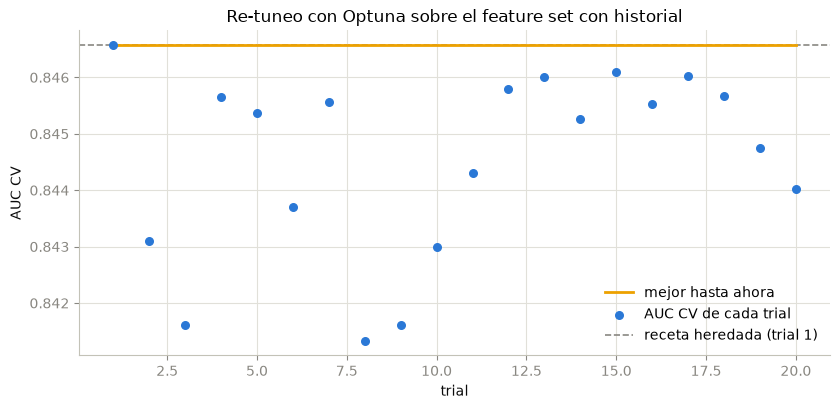

In [14]:
vals = [t.value for t in study.trials]
best_acum = np.maximum.accumulate(vals)
nums = np.arange(1, len(vals) + 1)

fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(nums, best_acum, color=C_AMARILLO, lw=2, label="mejor hasta ahora", zorder=2)
ax.scatter(nums, vals, color=C_AZUL, s=30, label="AUC CV de cada trial", zorder=3)
ax.axhline(vals[0], color=C_MUTED, ls="--", lw=1.2, label="receta heredada (trial 1)", zorder=1)
ax.set_xlabel("trial")
ax.set_ylabel("AUC CV")
ax.set_title("Re-tuneo con Optuna sobre el feature set con historial")
ax.legend(frameon=False, loc="lower right")
plt.tight_layout()
plt.show()

### Ventana de datos, quinta pasada

El historial fino cambia el trade-off otra vez, y esta vez en una dirección interesante: aunque la ventana recorte las **filas de entrenamiento** a 24 meses, las features de historial se calculan sobre **todo el pasado** (los conteos, recencias y tasas de una fila reciente resumen años de historia). Es decir: la historia vieja ahora entra al modelo *destilada en las features* aunque sus filas no entren crudas — el costo de los "datos rancios" podría bajar. Re-test {12, 24, 36, toda la historia} con receta y feature set finales; sanidad: la fila de 24 debe reproducir el cierre de Optuna.

In [15]:
log_progreso("=== Re-test de ventana (receta y feature set finales) ===")
resultados_v = []
for ventana in [12, 24, 36, None]:
    etiqueta = "toda la historia" if ventana is None else f"{ventana} meses"
    auc, _, rondas, _ = evaluar_cv_historial(CAT_FINAL, NUM_META, COLS_HIST, RECETA_H,
                                             ventana=ventana, etiqueta=f"ventana {etiqueta}")
    resultados_v.append({"ventana": etiqueta, "meses": ventana, "auc_cv": auc, "rondas": rondas})

res_v = pd.DataFrame(resultados_v).sort_values("auc_cv", ascending=False).reset_index(drop=True)
print("\n" + res_v[["ventana", "auc_cv"]].round(4).to_string(index=False))

VENTANA_H = res_v.loc[0, "meses"]
VENTANA_H = None if pd.isna(VENTANA_H) else int(VENTANA_H)
AUC_CIERRE_CV = float(res_v.loc[0, "auc_cv"])
NROUNDS_H = int(round(float(res_v.loc[0, "rondas"])))

fila_24 = res_v[res_v["meses"] == 24]["auc_cv"].iloc[0]
log_progreso(f"sanidad: 24 meses reproduce el cierre de Optuna? {fila_24:.4f} vs. {AUC_CIERRE_OPT:.4f}")
etiqueta_vh = "toda la historia" if VENTANA_H is None else f"{VENTANA_H} meses"
log_progreso(f"decision de ventana: {etiqueta_vh} -> AUC CV de cierre {AUC_CIERRE_CV:.4f} | NROUNDS_H={NROUNDS_H}")

[22:53:56] === Re-test de ventana (receta y feature set finales) ===
[22:54:40] ventana 12 meses                                     -> AUC CV 0.8448 | folds [0.7946 0.8449 0.8937 0.8458] | rondas prom 260 |   44s
[22:55:50] ventana 24 meses                                     -> AUC CV 0.8466 | folds [0.7939 0.8454 0.8960 0.8510] | rondas prom 358 |   70s
[22:56:56] ventana 36 meses                                     -> AUC CV 0.8452 | folds [0.7904 0.8456 0.8932 0.8517] | rondas prom 304 |   66s
[22:58:29] ventana toda la historia                             -> AUC CV 0.8450 | folds [0.7920 0.8441 0.8942 0.8496] | rondas prom 374 |   93s

         ventana  auc_cv
        24 meses  0.8466
        36 meses  0.8452
toda la historia  0.8450
        12 meses  0.8448
[22:58:29] sanidad: 24 meses reproduce el cierre de Optuna? 0.8466 vs. 0.8466
[22:58:29] decision de ventana: 24 meses -> AUC CV de cierre 0.8466 | NROUNDS_H=358


### Comparación final honesta en `test_interno` (única mirada)

Protocolo reforzado de las Clases 4–5: rondas fijadas por la CV (`NROUNDS_H`), sin early stopping contra `test_interno`, watchlist solo para mirar. Las columnas de historial se construyen igual que en producción: para las filas de train (filtradas a la ventana), expanding estricto; para las filas de `test_interno`, tasas **congeladas al final de `df_train`** — todo el pasado etiquetado disponible en ese escenario. La vara: **0.8377** de la Clase 5.

In [16]:
exp_full = {c: expanding_skip_rate(df_train, HIST_SPECS[c]) for c in COLS_HIST}

df_tr_final = filtrar_reciente(df_train, VENTANA_H).copy()
df_te_final = df_test_interno.copy()
for c in COLS_HIST:
    df_tr_final[c] = exp_full[c].loc[df_tr_final.index]
    df_te_final[c] = frozen_skip_rate(df_train, df_te_final, HIST_SPECS[c])

df_ambos = pd.concat([df_tr_final, df_te_final])
X_ambos, y_ambos, names_ambos = build_sparse_matrix(df_ambos, CAT_FINAL, list(NUM_META) + list(COLS_HIST))
n_tr = len(df_tr_final)
dtr_final = xgb.DMatrix(X_ambos[:n_tr], label=y_ambos[:n_tr], feature_names=names_ambos)
dte_final = xgb.DMatrix(X_ambos[n_tr:], label=y_ambos[n_tr:], feature_names=names_ambos)

booster_final = xgb.train(
    {**BASE_PARAMS_XGB, **RECETA_H}, dtr_final,
    num_boost_round=NROUNDS_H,
    evals=[(dtr_final, "train"), (dte_final, "test_interno")],
    verbose_eval=50,
)

pred_test = booster_final.predict(dte_final)
auc_test_h = roc_auc_score(y_ambos[n_tr:], pred_test)

print(f"\nRondas fijadas por la CV (NROUNDS_H): {NROUNDS_H}")
print(f"AUC test_interno -- Clase 5:        {AUC_CLASE5_TEST:.4f}")
print(f"AUC test_interno -- historial fino: {auc_test_h:.4f}")
print(f"Mejora:                             {auc_test_h - AUC_CLASE5_TEST:+.4f}")
log_progreso(f"TEST_INTERNO (unica mirada): historial {auc_test_h:.4f} vs. Clase 5 {AUC_CLASE5_TEST:.4f} "
             f"({auc_test_h - AUC_CLASE5_TEST:+.4f})")

[0]	train-auc:0.82986	test_interno-auc:0.78624
[50]	train-auc:0.86057	test_interno-auc:0.83272
[100]	train-auc:0.86780	test_interno-auc:0.83763
[150]	train-auc:0.87335	test_interno-auc:0.83984
[200]	train-auc:0.87706	test_interno-auc:0.84157
[250]	train-auc:0.88009	test_interno-auc:0.84236
[300]	train-auc:0.88324	test_interno-auc:0.84273
[350]	train-auc:0.88555	test_interno-auc:0.84315
[357]	train-auc:0.88596	test_interno-auc:0.84316

Rondas fijadas por la CV (NROUNDS_H): 358
AUC test_interno -- Clase 5:        0.8377
AUC test_interno -- historial fino: 0.8432
Mejora:                             +0.0055
[22:58:56] TEST_INTERNO (unica mirada): historial 0.8432 vs. Clase 5 0.8377 (+0.0055)


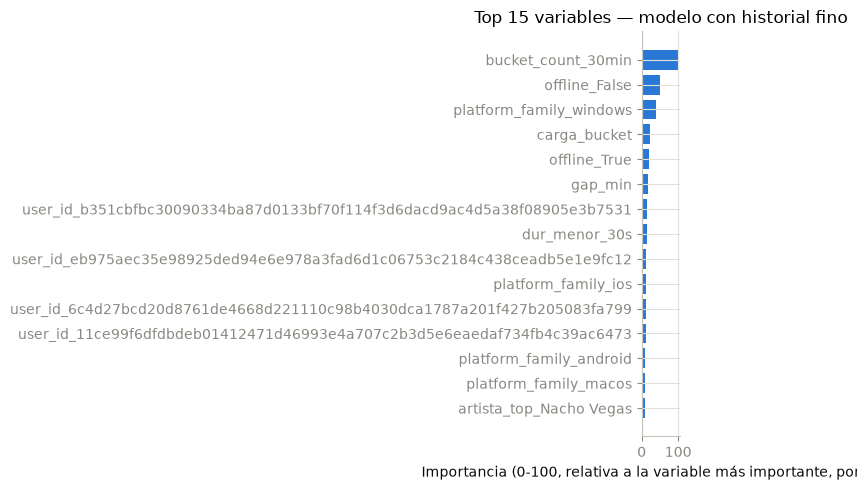

Variables usadas: 100 de 138 columnas
Features de historial dentro del top 15: []


In [17]:
importancias = booster_final.get_score(importance_type="gain")
imp_df = pd.DataFrame(list(importancias.items()), columns=["feature", "gain"]).sort_values("gain", ascending=False)
imp_df["gain_norm"] = 100 * imp_df["gain"] / imp_df["gain"].max()

top_n = 15
top_imp = imp_df.head(top_n).iloc[::-1]

plt.figure(figsize=(7, 5))
plt.barh(top_imp["feature"], top_imp["gain_norm"], color=C_AZUL)
plt.xlabel("Importancia (0-100, relativa a la variable más importante, por gain)")
plt.title(f"Top {top_n} variables — modelo con historial fino")
plt.tight_layout()
plt.show()

nuevas = [f for f in imp_df["feature"].head(top_n)
          if f.startswith(("u_track", "u_art", "user_skip", "track_skip"))]
print(f"Variables usadas: {len(imp_df)} de {len(names_ambos)} columnas")
print(f"Features de historial dentro del top {top_n}: {nuevas}")

### Modelo final: reentrenar con el 100% de los datos y submission

Detalles de correctitud, los heredados más los nuevos del historial:

- **Heredados**: `gap_min` con continuidad train→test; conteos de bucket/día y `gap_siguiente` autocontenidos en test; columnas de la API por URI (tabla estática, mismo helper).
- **Historial de metadata** (nuevo): `u_track_veces`/`u_track_recencia`/`u_art_*` se calculan sobre train+test concatenados en orden cronológico — para una fila de test, "las veces que la escuchó antes" incluye las reproducciones de train **y** las de test anteriores a ella. Legítimo por el mismo argumento batch de siempre: son `ts`/IDs, metadata que el archivo de test trae completa, ningún target involucrado.
- **Historial de target** (nuevo): para las filas de test, las tasas se congelan al **final del train completo** (2024-08-31) — no existe ningún label después de esa fecha, y la construcción lo respeta exactamente igual que la CV respetó los bordes de fold. Para las filas de train del modelo final, expanding estricto (los labels pasados sí existen al momento de entrenar).

In [18]:
train_completo = pd.concat([df_train, df_test_interno]).sort_values(["ts_dt", "obs_id"]).reset_index(drop=True)

test_raw = pd.read_csv(
    f"{DATA_DIR}/test_data.txt", sep="\t",
    usecols=[c for c in USECOLS if c != "ms_played"], dtype=DTYPES, low_memory=False,
)
test_raw["content_type"] = np.select(
    [test_raw["spotify_track_uri"].notna(),
     test_raw["spotify_episode_uri"].notna(),
     test_raw["audiobook_uri"].notna()],
    ["track", "episode", "audiobook"],
    default="desconocido",
)
test_raw["ts_dt"] = pd.to_datetime(test_raw["ts"], utc=True, format="ISO8601")
test_raw["hora"] = test_raw["ts_dt"].dt.hour
test_raw["dia_semana"] = test_raw["ts_dt"].dt.dayofweek.map(dict(enumerate(DIAS)))
test_raw["artista_top"] = test_raw[col_artista].where(test_raw[col_artista].isin(TOP_ARTISTAS), "otros")

# gap_min con continuidad real train->test
combinado = pd.concat([
    train_completo[["obs_id", "user_id", "ts_dt"]],
    test_raw[["obs_id", "user_id", "ts_dt"]],
]).sort_values(["ts_dt", "obs_id"])
combinado["gap_min"] = combinado.groupby("user_id")["ts_dt"].diff().dt.total_seconds() / 60.0
test_raw["gap_min"] = test_raw["obs_id"].map(combinado.set_index("obs_id")["gap_min"]).fillna(-1)

# conteos autocontenidos en test
test_raw["bucket_count_30min"] = test_raw.groupby(["user_id", "ts"])["obs_id"].transform("size")
test_raw["pos_en_bucket"] = test_raw.groupby(["user_id", "ts"]).cumcount()
fecha_test = test_raw["ts_dt"].dt.floor("D")
test_raw["bucket_count_dia"] = test_raw.groupby(["user_id", fecha_test])["obs_id"].transform("size")
gap_sig_test = (test_raw.groupby("user_id")["ts_dt"].shift(-1) - test_raw["ts_dt"]).dt.total_seconds() / 60.0
test_raw["gap_siguiente"] = gap_sig_test.fillna(-1)

# API (despues de bucket_count, que carga_bucket lo necesita) y claves de historial
test_raw = agregar_columnas_api(test_raw)
test_raw["uri_key"] = test_raw["uri"].fillna("sin_uri")
test_raw["artista_key"] = test_raw[col_artista].fillna("sin_artista")

# Historial de metadata con continuidad train->test (expanding cronologico sobre la union)
cols_hist_meta = ["obs_id", "user_id", "ts_dt", "uri_key", "artista_key"]
comb_h = pd.concat([train_completo[cols_hist_meta], test_raw[cols_hist_meta]]).sort_values(["ts_dt", "obs_id"])
gt = comb_h.groupby(["user_id", "uri_key"], sort=False)
comb_h["u_track_veces"] = gt.cumcount()
comb_h["u_track_recencia"] = (gt["ts_dt"].diff().dt.total_seconds() / 60.0).fillna(-1)
ga = comb_h.groupby(["user_id", "artista_key"], sort=False)
comb_h["u_art_veces"] = ga.cumcount()
comb_h["u_art_recencia"] = (ga["ts_dt"].diff().dt.total_seconds() / 60.0).fillna(-1)
comb_h = comb_h.set_index("obs_id")
for c in ["u_track_veces", "u_track_recencia", "u_art_veces", "u_art_recencia"]:
    test_raw[c] = test_raw["obs_id"].map(comb_h[c])

# Historial de target: train expanding / test congelado al final del train completo
exp_tc = {c: expanding_skip_rate(train_completo, HIST_SPECS[c]) for c in COLS_HIST}
train_final_full = filtrar_reciente(train_completo, VENTANA_H).copy()
for c in COLS_HIST:
    train_final_full[c] = exp_tc[c].loc[train_final_full.index]
    test_raw[c] = frozen_skip_rate(train_completo, test_raw, HIST_SPECS[c])

log_progreso(f"test de Kaggle preparado: {len(test_raw):,} filas | re-escuchas de cancion en test: "
             f"{(test_raw['u_track_veces'] > 0).mean():.1%}")

df_ambos_kaggle = pd.concat([train_final_full, test_raw])
X_ak, y_ak, names_ak = build_sparse_matrix(df_ambos_kaggle, CAT_FINAL, list(NUM_META) + list(COLS_HIST))
n_tr_k = len(train_final_full)

dtrain_kaggle = xgb.DMatrix(X_ak[:n_tr_k], label=y_ak[:n_tr_k], feature_names=names_ak)
dtest_kaggle = xgb.DMatrix(X_ak[n_tr_k:], feature_names=names_ak)

modelo_final = xgb.train({**BASE_PARAMS_XGB, **RECETA_H}, dtrain_kaggle, num_boost_round=NROUNDS_H)
test_pred = modelo_final.predict(dtest_kaggle)

submission = pd.DataFrame({"obs_id": test_raw["obs_id"], "target": test_pred})
submission.to_csv("../submissions/submission_historial_fino.csv", index=False)
print(f"Guardado submission_historial_fino.csv -- {len(submission)} filas | "
      f"probs en [{test_pred.min():.4f}, {test_pred.max():.4f}], media {test_pred.mean():.4f}")

etiqueta_vh = "toda la historia" if VENTANA_H is None else f"{VENTANA_H} meses"
log_progreso(f"submission guardada: submission_historial_fino.csv ({len(submission)} filas, "
             f"{NROUNDS_H} rondas, train {n_tr_k:,} filas a {etiqueta_vh})")
log_progreso(f"RESUMEN FINAL historial: AUC CV {AUC_CIERRE_CV:.4f} (Clase 5: {AUC_CLASE5_CV:.4f}, {AUC_CIERRE_CV - AUC_CLASE5_CV:+.4f}) | "
             f"test_interno {auc_test_h:.4f} (Clase 5: {AUC_CLASE5_TEST:.4f}, {auc_test_h - AUC_CLASE5_TEST:+.4f}) | "
             f"receta {RECETA_H} | ventana {etiqueta_vh}")
submission.head()

[22:58:59] test de Kaggle preparado: 51,570 filas | re-escuchas de cancion en test: 87.9%
Guardado submission_historial_fino.csv -- 51570 filas | probs en [0.0048, 0.9954], media 0.2577
[22:59:07] submission guardada: submission_historial_fino.csv (51570 filas, 358 rondas, train 218,339 filas a 24 meses)
[22:59:07] RESUMEN FINAL historial: AUC CV 0.8466 (Clase 5: 0.8420, +0.0046) | test_interno 0.8432 (Clase 5: 0.8377, +0.0055) | receta {'max_depth': 7, 'eta': 0.030223664895420776, 'min_child_weight': 2, 'subsample': 0.7963585977878456, 'colsample_bytree': 0.79208902443077, 'gamma': 0.8414960952850874} | ventana 24 meses


,obs_id,target
0,911345,0.135803
1,911346,0.071731
2,911347,0.068708
3,911348,0.024267
4,911349,0.026901


### Notas honestas para el informe — historial fino (con los números de la corrida ejecutada)

- **Qué se agregó:** historial fino por (usuario, canción) y (usuario, artista) en dos familias con estatus metodológico distinto — metadata (conteos/recencia, expanding libre, legitimidad batch como `gap_min`) y target (skip-rates, con las tasas de las filas de validación **congeladas en el borde de cada fold** — el escenario real de Kaggle, donde no hay labels dentro del período de test). Re-tuneo corto con Optuna (20 trials), ventana re-testeada (quinta pasada), `test_interno` una única vez. Corrida completa ~22 min (`progreso_historial.log`); sanidad inicial reprodujo el 0.8420 de la Clase 5 exacto.
- **Adoptado: solo H1** (`u_track_veces`, `u_track_recencia`) → **AUC CV 0.8466 (+0.0046)**, mejorando los 4 folds. Cobertura: 81.8% de re-escuchas en train, 87.9% en el test real.
- **Rechazados con evidencia:** H2 artista (−0.0002, redundante con H1); y los tres grupos de skip-rate (−0.0053/−0.0060/−0.0065) — el desajuste train/producción del target encoding temporal: expanding en train es casi el target disfrazado, congelado al borde en validación llega rancio; el modelo desplaza señal genuina. Una CV con fuga los habría celebrado — el triple rechazo es el control honesto funcionando. Rescate posible anotado: suavizado y/o versión de train con rezago.
- **Optuna: ningún trial superó a la receta heredada** (trial 1 = 0.8466 exacto, sanidad OK) — segunda vez consecutiva que la receta resulta robusta a un cambio de features, tal cual la experiencia del profesor.
- **Ventana re-validada (quinta): 24 meses** (0.8466) vs. 12 (0.8448), 36 (0.8452), toda la historia (0.8450). La hipótesis "el historial destila la historia vieja y los datos rancios duelen menos" movió los números en esa dirección (36m y todo quedaron más cerca que antes) pero no cambió la decisión. `NROUNDS_H = 358`.
- **`test_interno` (única mirada, rondas fijadas): 0.8432 vs. 0.8377 de la Clase 5 (+0.0055)** — delta en línea con el de la CV (+0.0046), la consistencia que venimos viendo desde la Clase 5.
- **Submission:** `submission_historial_fino.csv` (51.570 filas; train 100% a 24 meses = 218.339 filas, 358 rondas). **Score público en Kaggle: 0.85775** (vs. 0.84993 de la Clase 5, **+0.0078** — mejor score nuestro; la brecha con el puntero (~0.89) baja a ~3 puntos). La heurística del delta de CV (+0.0046 → esperado ~0.8545) funcionó esta vez como **piso**: Kaggle pagó más que la CV. Es la contracara exacta de la Clase 5, y confirma el modelo mental completo: la señal *estática* (API) rinde en Kaggle lo mismo que en la CV; la señal de *comportamiento* (historial) rinde más, porque cobra el bonus de entrenar pegado al test (el modelo final entrena hasta ago-2024, con conteos y recencias frescos) y porque su cobertura crece en el período de test (87.9% de re-escuchas vs. 81.8% en train). Las dos caras, confirmadas con submissions reales.